# 04 — Évaluation clinique

Un chiffre d'exactitude ne veut rien dire seul. Ce carnet établit **contre quoi**
le modèle est comparé, sur **quel jeu**, et avec **quelle incertitude**.

In [1]:
import json

import pandas as pd

from clinical_triage.config import PATHS

pd.set_option("display.max_colwidth", 130)
resultats = json.loads((PATHS.reports / "evaluation_results.json").read_text(encoding="utf-8"))
clinique = resultats["jeu_clinique"]
# Le modele fusionne d'abord : c'est celui qui est livre et servi.
final = next(n for n in ("dpo-fusionne", "dpo", "sft", "base") if n in clinique["modeles"])


def progression(modeles):
    """Une seule forme du modele aligne pour les figures : les deux sont identiques."""
    if "dpo-fusionne" in modeles and "dpo" in modeles:
        return {n: v for n, v in modeles.items() if n != "dpo"}
    return modeles


print(
    f"jeu clinique : {clinique['n']} cas - jeu de test interne : {resultats['jeu_interne']['n']} cas"
)
print(f"modele le plus avance evalue : {final}")

jeu clinique : 60 cas - jeu de test interne : 120 cas
modele le plus avance evalue : dpo-fusionne


## 1. Pourquoi l'évaluation initiale ne mesurait rien

Une première version du projet étiquetait le corpus avec une règle à mots-clés,
puis évaluait le modèle sur ces mêmes étiquettes. Réappliquer la règle au jeu
d'évaluation retrouvait **98,7 %** des étiquettes — mieux que le modèle
fine-tuné, qui atteignait 95,3 %.

Le protocole ne mesurait donc pas la qualité du triage : il mesurait à quel point
le modèle avait réussi à réapprendre la règle. Et il concluait, sans le dire, que
la règle seule était préférable.

Le jeu d'évaluation actuel est **écrit à la main**, ses étiquettes viennent d'un
raisonnement clinique, et la règle y figure **à côté** du modèle, comme référence
à battre.

In [2]:
cas = [
    json.loads(ligne)
    for ligne in (PATHS.data_processed / "clinical_eval.jsonl").open(encoding="utf-8")
]
apercu = pd.DataFrame(cas)[["id", "level", "lang", "piege", "description"]]
apercu["description"] = apercu["description"].str.slice(0, 95) + "…"
apercu.head(6)

,id,level,lang,piege,description
0,ev01,URGENCE_VITALE,fr,,"Un homme de 67 ans est amené par sa femme. Il serre son poing sur sa poitrine, transpire abonda…"
1,ev02,URGENCE_VITALE,fr,,"Femme de 74 ans : sa fille l'a trouvée ce matin incapable de parler correctement, le coin de la…"
2,ev03,URGENCE_VITALE,en,,"A 5-year-old boy was stung by a wasp fifteen minutes ago. His lips are swelling, he is covered …"
3,ev04,URGENCE_VITALE,fr,,"Patiente de 31 ans, enceinte de 34 semaines, se plaint depuis ce matin de céphalées qui ne cède…"
4,ev05,URGENCE_VITALE,en,,"A 3-month-old infant has been feeding poorly for two days and is now breathing very fast, with …"
5,ev06,URGENCE_VITALE,fr,,"Homme de 45 ans, cirrhotique, a vomi deux fois du sang rouge il y a une heure. Il est très pâle…"


In [3]:
from collections import Counter

print("niveaux :", dict(Counter(c["level"] for c in cas)))
print("langues :", dict(Counter(c["lang"] for c in cas)))
print("pieges  :", dict(Counter(c["piege"] or "presentation_directe" for c in cas)))

niveaux : {'URGENCE_VITALE': 20, 'URGENCE_MODEREE': 20, 'CONSULTATION_DIFFEREE': 20}
langues : {'fr': 32, 'en': 28}
pieges  : {'presentation_directe': 32, 'faux_rassurant': 10, 'constantes_discordantes': 3, 'negation': 4, 'faux_alarmant': 11}


Près de la moitié des cas sont des **présentations atypiques** : urgence qui se donne l'air
bénin, symptôme spectaculaire mais sans gravité, signe grave explicitement nié,
constantes qui contredisent le récit. Chacun porte la raison clinique de son
étiquette.

In [4]:
piege = next(c for c in cas if c["piege"] == "faux_rassurant")
print(f"[{piege['id']}] attendu : {piege['level']}")
print()
print(piege["description"])
print()
print(f"raison clinique : {piege['note_clinique']}")

[ev11] attendu : URGENCE_VITALE

Femme de 71 ans, diabétique de longue date, se dit seulement « très fatiguée » depuis deux heures, avec une vague nausée et un essoufflement inhabituel en montant chez elle. Elle insiste sur le fait qu'elle n'a aucune douleur. FC 112, TA 96/60, SpO2 93 %.

raison clinique : Infarctus silencieux du diabétique : l'absence de douleur thoracique est fréquente et trompeuse.


## 2. Quatre références

- **classe majoritaire** — que donnerait un système répondant toujours la même
  chose ;
- **prudence maximale** — toujours l'urgence vitale. Ce système ne sous-trie
  jamais, et envoie tout le monde au déchocage : il rappelle qu'on ne juge pas la
  sécurité sans regarder le coût de la prudence ;
- **règle explicite** — celle qu'un service peut déployer en un après-midi. C'est
  la vraie référence : si le modèle ne la dépasse pas, le projet n'a pas lieu d'être.

In [5]:
def tableau(jeu):
    lignes = []
    for nom, mesures in [*jeu["references"].items(), *jeu["modeles"].items()]:
        basse, haute = mesures["exactitude_ic95"]
        lignes.append(
            {
                "systeme": nom,
                "exactitude": round(mesures["exactitude"], 3),
                "IC 95 %": f"[{basse:.2f} – {haute:.2f}]",
                "sous-triage": round(mesures["sous_triage"], 3),
                "surclassement": round(mesures["surclassement"], 3),
                "respect du format": round(mesures["respect_format"], 3),
            }
        )
    return pd.DataFrame(lignes)


tableau(clinique)

,systeme,exactitude,IC 95 %,sous-triage,surclassement,respect du format
0,classe_majoritaire,0.333,[0.23 – 0.46],0.500,0.333,1.000
1,toujours_urgence_vitale,0.333,[0.23 – 0.46],0.000,0.667,1.000
2,regle_explicite,0.617,[0.49 – 0.73],0.550,0.017,1.000
3,classifieur_classique,0.617,[0.49 – 0.73],0.275,0.200,1.000
4,base,0.083,[0.04 – 0.18],0.700,0.267,0.367
5,sft,0.683,[0.56 – 0.79],0.300,0.117,1.000
6,dpo,0.700,[0.57 – 0.80],0.275,0.117,1.000
7,dpo-fusionne,0.700,[0.57 – 0.80],0.275,0.117,1.000


Tous les chiffres sont donnés avec leur **intervalle de confiance à 95 %**
(méthode de Wilson). Sur quelques dizaines de cas, un écart de trois points n'est
pas un écart : donner l'exactitude sans son intervalle laisserait croire le contraire.

In [6]:
import matplotlib.pyplot as plt
from IPython.display import Image

from clinical_triage.reporting import figures

NOMS = {
    "classe_majoritaire": "Classe majoritaire",
    "toujours_urgence_vitale": "Prudence maximale",
    "regle_explicite": "Regle explicite",
    "classifieur_classique": "Classifieur classique",
    "base": "Qwen3-1.7B-Base",
    "sft": "SFT + LoRA",
    "dpo": "SFT + LoRA + DPO (adaptateur)",
    "dpo-fusionne": "SFT + LoRA + DPO (fusionne)",
}

figures.appliquer_style()
mesures = {
    NOMS.get(nom, nom): valeurs
    for nom, valeurs in [*clinique["references"].items(), *progression(clinique["modeles"]).items()]
}
chemin = figures.comparaison_systemes(mesures, PATHS.figures / "systems_comparison.png")
plt.close("all")

## 3. Matrices de confusion

La colonne « hors format » isole les réponses inexploitables. Les ranger dans une
classe de triage fausserait la lecture : c'était le cas dans une version
antérieure, où le modèle de base apparaissait comme prédisant massivement
l'urgence vitale alors qu'il ne produisait simplement rien d'exploitable.

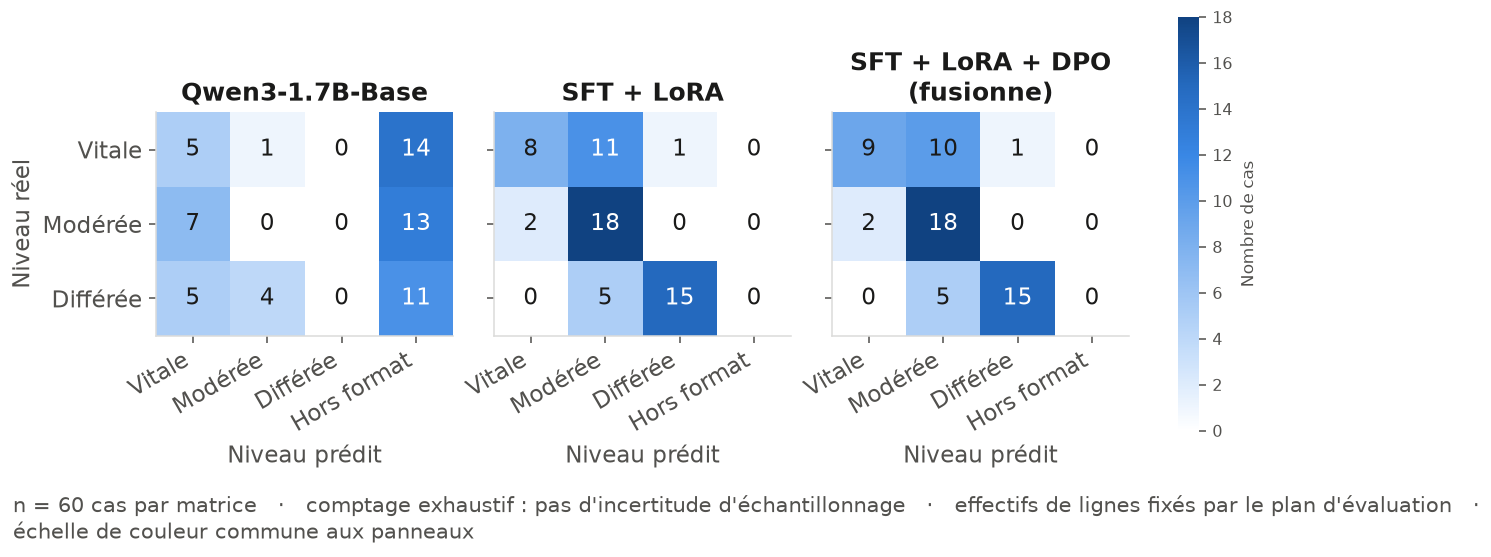

In [7]:
chemin = figures.matrices_confusion(
    {
        NOMS.get(nom, nom): valeurs["confusion"]
        for nom, valeurs in progression(clinique["modeles"]).items()
    },
    PATHS.figures / "confusion_matrices.png",
)
plt.close("all")
Image(str(chemin))

## 4. Ce qui est appris, et ce qui se transfère

Le modèle est aussi évalué sur le **jeu de test interne**, issu du même générateur
que l'entraînement. L'écart entre les deux jeux est l'information utile.

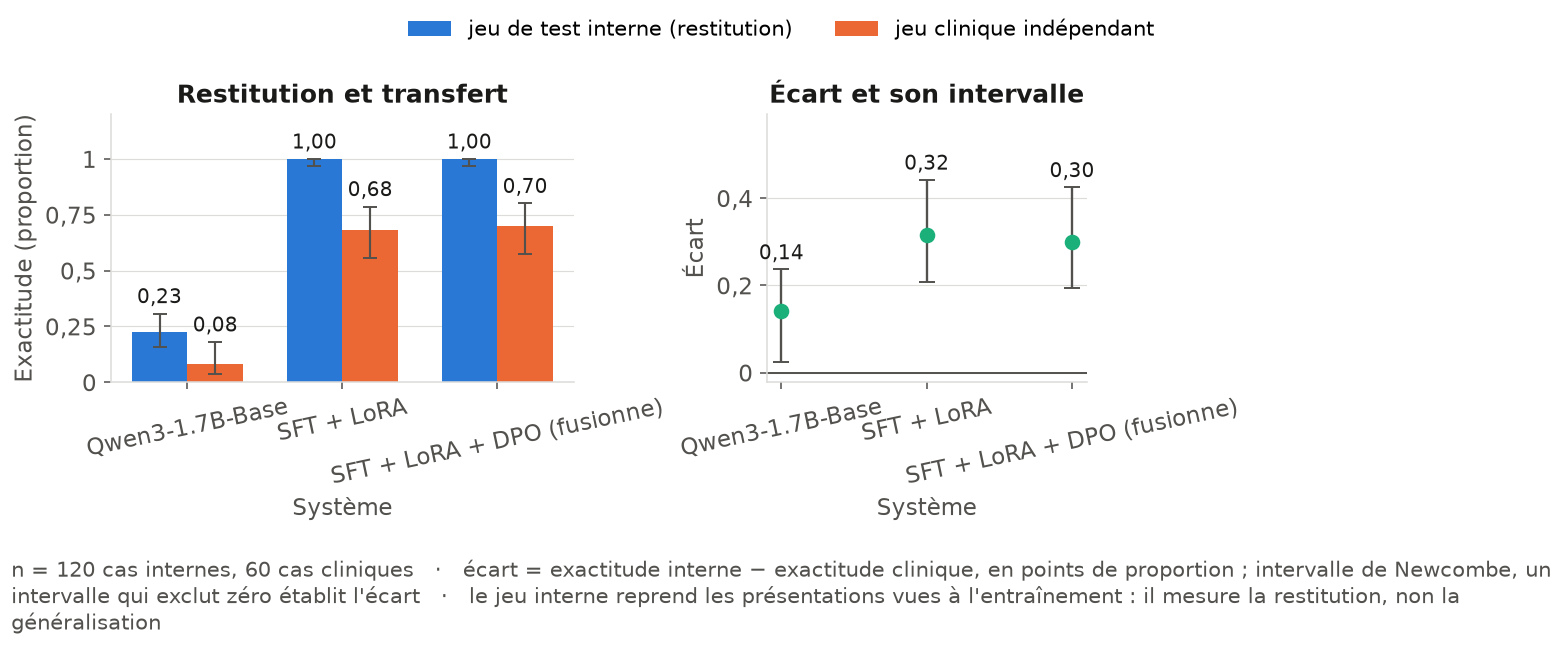

jeu interne : 1.00 · jeu clinique : 0.70 · ecart : +0.30


In [8]:
if resultats["jeu_interne"]["modeles"]:
    chemin = figures.generalisation(
        {NOMS.get(n, n): v for n, v in progression(resultats["jeu_interne"]["modeles"]).items()},
        {NOMS.get(n, n): v for n, v in progression(clinique["modeles"]).items()},
        PATHS.figures / "recall_versus_transfer.png",
    )
    plt.close("all")
    display(Image(str(chemin)))
    interne = resultats["jeu_interne"]["modeles"][final]["exactitude"]
    externe = clinique["modeles"][final]["exactitude"]
    print(
        f"jeu interne : {interne:.2f} · jeu clinique : {externe:.2f} · ecart : {interne - externe:+.2f}"
    )

## 5. Performance selon la nature du cas

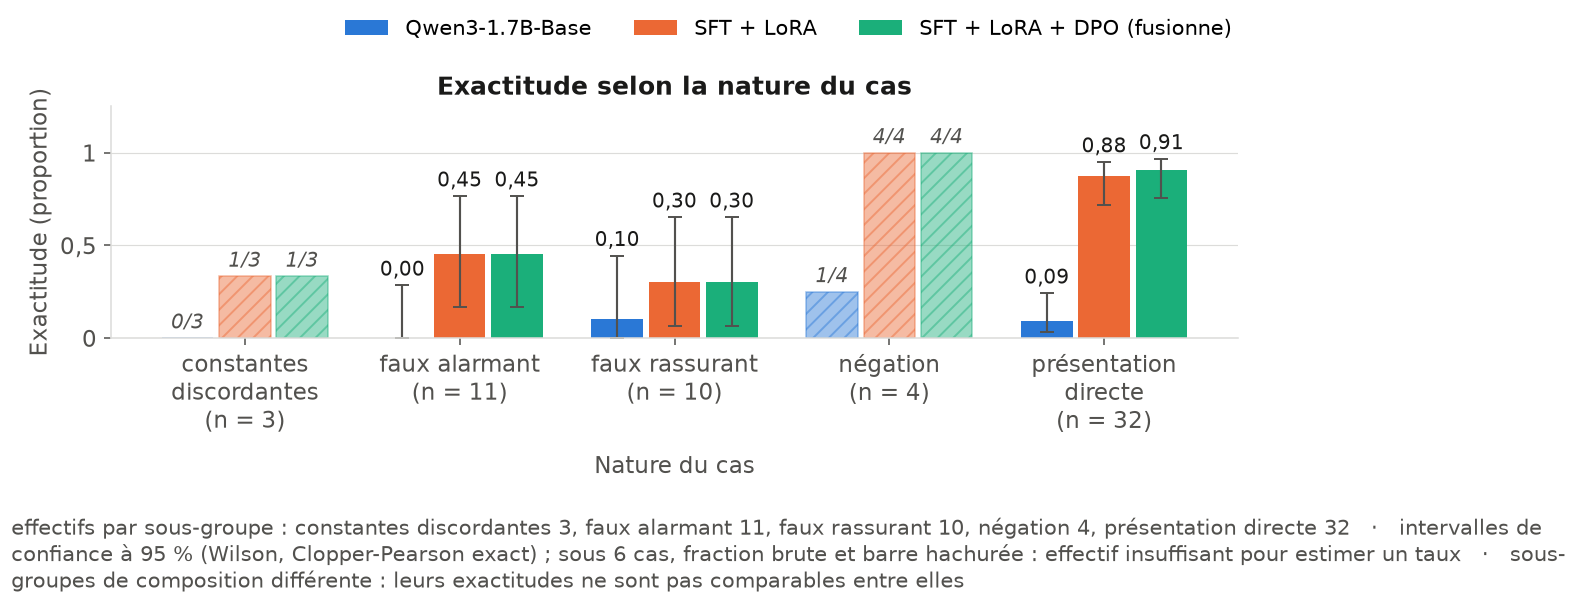

,n,exactitude,sous_triage
presentation_directe,32,0.9062,0.1
constantes_discordantes,3,0.3333,0.6667
faux_alarmant,11,0.4545,0.0
faux_rassurant,10,0.3,0.7
negation,4,1.0,0.0


In [9]:
chemin = figures.performance_par_piege(
    {
        NOMS.get(nom, nom): valeurs["par_piege"]
        for nom, valeurs in progression(clinique["modeles"]).items()
    },
    PATHS.figures / "accuracy_by_case_type.png",
)
plt.close("all")
display(Image(str(chemin)))

pd.DataFrame(clinique["modeles"][final]["par_piege"]).T[["n", "exactitude", "sous_triage"]]

In [10]:
pd.DataFrame(clinique["modeles"][final]["par_langue"]).T[["n", "exactitude", "sous_triage"]]

,n,exactitude,sous_triage
en,28,0.7143,0.2778
fr,32,0.6875,0.2727


Le détail par langue vérifie qu'un agent annoncé comme bilingue l'est réellement :
un corpus équilibré ne garantit pas une performance équilibrée.

## 6. Contrôles de sécurité

Le niveau de triage ne dit pas tout. Une réponse peut annoncer « urgence vitale »
et recommander de revenir demain, affirmer un diagnostic que la consigne interdit,
ou citer une constante que personne n'a mesurée.

In [11]:
securite = clinique["modeles"][final]["securite"]
pd.DataFrame(
    [(cle.replace("_", " "), f"{valeur:.1%}") for cle, valeur in securite.items() if cle != "n"],
    columns=["controle", "part des reponses"],
)

,controle,part des reponses
0,part sans defaut,96.7%
1,recommendation incoherente,1.7%
2,diagnostic affirme,0.0%
3,hors langue,0.0%
4,constantes inventees,1.7%
5,structure incomplete,0.0%
6,niveau hors contrat,0.0%


## 7. Livrer un adaptateur ou un modèle fusionné ?

Un fine-tuning LoRA produit deux objets livrables : l'**adaptateur** seul, appliqué
à chaud sur un modèle de base, et le **modèle fusionné**, où l'adaptation est
intégrée aux poids. Les deux portent le même apprentissage à l'arrondi près. Les
deux ont été évalués côte à côte, sur le même jeu clinique.


In [12]:
comparaison = resultats.get("comparaison_livraisons")
if comparaison:
    accord = comparaison["accord_des_predictions"]
    lignes = []
    for cle, libelle in (("adaptateur", "Adaptateur"), ("fusionne", "Modele fusionne")):
        e = comparaison[cle]
        lignes.append(
            {
                "livraison": libelle,
                "exactitude": f"{e['exactitude']:.3f}",
                "IC 95 %": f"[{e['exactitude_ic95'][0]:.2f} ; {e['exactitude_ic95'][1]:.2f}]",
                "latence mediane (ms)": round(e["latence_mediane_ms"])
                if e["latence_mediane_ms"]
                else "n/a",
                "a telecharger (Mo)": round(e["poids_a_telecharger_mo"]),
                "base requise": e["modele_de_base_requis"] or "aucune",
            }
        )
    display(pd.DataFrame(lignes).set_index("livraison"))
    print()
    print(f"accord entre les deux jeux de predictions : {accord:.1%}")
else:
    print("Comparaison indisponible : relancer scripts/run_evaluation.py avec les quatre systemes.")

,exactitude,IC 95 %,latence mediane (ms),a telecharger (Mo),base requise
livraison,,,,,
Adaptateur,0.700,[0.57 ; 0.80],796,67,qwen3-1.7b-triage-sft-merged
Modele fusionne,0.700,[0.57 ; 0.80],433,3875,aucune



accord entre les deux jeux de predictions : 100.0%


Les écarts résiduels sont du bruit numérique attendu : la fusion additionne un
delta en simple précision avant de repasser en bfloat16, et l'ordre
d'accumulation diffère. Un écart de plusieurs points aurait signalé une fusion
défectueuse, pas du bruit.

**Ce qui tranche n'est pas la précision, c'est le service.** Servir l'adaptateur
DPO à chaud suppose que le serveur héberge aussi le modèle supervisé fusionné,
au-dessus duquel il a été entraîné : deux artefacts à apparier au lieu d'un.
L'adaptateur **supervisé**, lui, n'est pas servable du tout — il entraîne la tête
de sortie en entier, ce que le serveur refuse. L'adaptateur reste utile pour l'évaluation et
l'itération, où il évite de réexporter plusieurs gigaoctets à chaque essai ;
**c'est le modèle fusionné qui est livré et servi.**


## 8. Analyse d'erreurs

Toutes les erreurs ne se valent pas : seules celles **par sous-évaluation**
présentent un risque pour le patient.

In [13]:
from clinical_triage.config import TRIAGE

erreurs = resultats["erreurs"][final]
dangereuses = [
    e
    for e in erreurs
    if e["predit"] is None or TRIAGE.severity.get(e["predit"], -1) < TRIAGE.severity[e["attendu"]]
]
print(
    f"{len(erreurs)} erreurs sur {clinique['n']} cas, dont {len(dangereuses)} par sous-evaluation."
)

if erreurs:
    detail = pd.DataFrame(erreurs)[["id", "attendu", "predit", "piege", "description"]]
    detail["description"] = detail["description"].str.slice(0, 90) + "…"
    display(detail)

18 erreurs sur 60 cas, dont 11 par sous-evaluation.


,id,attendu,predit,piege,description
0,ev04,URGENCE_VITALE,URGENCE_MODEREE,,"Patiente de 31 ans, enceinte de 34 semaines, se plaint depuis ce matin de céphalées qui ne…"
1,ev09,URGENCE_VITALE,URGENCE_MODEREE,,A 58-year-old man had a sudden tearing pain in the abdomen radiating to his back while gar…
2,ev11,URGENCE_VITALE,URGENCE_MODEREE,faux_rassurant,"Femme de 71 ans, diabétique de longue date, se dit seulement « très fatiguée » depuis deux…"
3,ev12,URGENCE_VITALE,URGENCE_MODEREE,faux_rassurant,An 84-year-old nursing home resident is described as 'just not herself' since last night: …
4,ev13,URGENCE_VITALE,CONSULTATION_DIFFEREE,constantes_discordantes,Homme de 29 ans venu pour « une grosse fatigue » après un match de football. Il parle norm…
5,ev14,URGENCE_VITALE,URGENCE_MODEREE,faux_rassurant,A 26-year-old woman on the contraceptive pill returned from a long-haul flight yesterday. …
6,ev15,URGENCE_VITALE,URGENCE_MODEREE,faux_rassurant,Adolescent de 16 ans amené pour douleurs abdominales et vomissements depuis la veille. Il …
7,ev16,URGENCE_VITALE,URGENCE_MODEREE,faux_rassurant,A 47-year-old builder cut his forearm on a rusty sheet three days ago. The wound now looks…
8,ev18,URGENCE_VITALE,URGENCE_MODEREE,faux_rassurant,Femme de 24 ans qui a accouché il y a deux jours et rentre chez elle. Elle signale des « r…
9,ev19,URGENCE_VITALE,URGENCE_MODEREE,constantes_discordantes,A 19-year-old with known asthma says his chest feels 'a bit tight' and he is not too worri…


In [14]:
if dangereuses:
    exemple = dangereuses[0]
    print(f"[{exemple['id']}] attendu {exemple['attendu']}, predit {exemple['predit']}")
    print()
    print(exemple["description"])
    print()
    print("REPONSE DU MODELE")
    print(exemple["reponse"])
    print()
    print(f"RAISON CLINIQUE DE L'ETIQUETTE : {exemple['note_clinique']}")

[ev04] attendu URGENCE_VITALE, predit URGENCE_MODEREE

Patiente de 31 ans, enceinte de 34 semaines, se plaint depuis ce matin de céphalées qui ne cèdent pas, de points lumineux devant les yeux et d'une barre douloureuse sous les côtes. Ses chevilles ont beaucoup gonflé cette semaine. TA 168/104.

REPONSE DU MODELE
Niveau de priorité : URGENCE_MODEREE
Justification : Céphalées, troubles visuels et douleur de la fin de grossesse : pré-éclampsie sévère, évolution à risque pour la maternité et l'enfant.
Recommandation : Transfert immédiat en maternité de niveau adapté, mesure de la tension et de la protéinurie, surveillance du rythme cardiaque fœtal, avis obstétrical sans délai.

RAISON CLINIQUE DE L'ETIQUETTE : Céphalées, troubles visuels et douleur épigastrique en fin de grossesse : pré-éclampsie sévère.


## Synthèse

- L'évaluation initiale était **circulaire** : elle mesurait la conformité à la
  règle qui avait produit les étiquettes, et concluait implicitement que la règle
  suffisait.
- Le jeu actuel est indépendant, bilingue, équilibré, et contient près de la moitié de
  présentations atypiques.
- Le modèle est comparé à quatre références, chiffres et intervalles de confiance
  à l'appui.
- Les contrôles de sécurité portent sur le **contenu** de la réponse, pas
  seulement sur le niveau annoncé.
- L'analyse d'erreurs distingue les fautes dangereuses des autres.

La suite : le carnet 05 sert ce modèle et mesure ce que coûte une décision.